# 🛒 E-commerce Product Recommendation System
## Notebook 4: XGBoost Training + Optuna + SHAP

**Goal:** Train an XGBoost model to predict purchase probability for (customer, product) pairs.

### Steps:
1. Load train/test data + prepare features
2. Baseline XGBoost model
3. Optuna hyperparameter tuning
4. Train final model on best params
5. SHAP explainability
6. Save model

---
## 1. Imports + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import optuna
import shap
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Load datasets from Notebook 03
train_data = pd.read_csv('../data/train_data.csv')
test_data  = pd.read_csv('../data/test_data.csv')

print(f'Train: {train_data.shape} | Test: {test_data.shape}')
print(f'Columns: {train_data.columns.tolist()}')

Train: (1025731, 14) | Test: (230603, 14)
Columns: ['CustomerID', 'Description', 'label', 'LastPurchaseDate', 'Frequency', 'Monetary', 'Recency', 'TotalUnitsSold', 'UniqueBuyers', 'AvgTransactionValue', 'Category', 'CategoryAffinity', 'CategoryCount', 'TimesBought']


---
## 2. Prepare Features

XGBoost requires all features to be numeric.  
- Drop non-feature columns (CustomerID, Description, LastPurchaseDate)
- Encode categorical feature (Category) using LabelEncoder
- Define feature matrix X and target vector y

In [2]:
# Columns to drop — identifiers and date, not features
DROP_COLS = ['CustomerID', 'Description', 'label', 'LastPurchaseDate']

# Encode Category — XGBoost needs numeric input
# LabelEncoder maps each category string to an integer
le = LabelEncoder()
train_data['Category'] = le.fit_transform(train_data['Category'].astype(str))
test_data['Category']  = le.transform(test_data['Category'].astype(str))

# Feature matrix and target
FEATURE_COLS = [c for c in train_data.columns if c not in DROP_COLS]

X_train = train_data[FEATURE_COLS]
y_train = train_data['label']
X_test  = test_data[FEATURE_COLS]
y_test  = test_data['label']

print(f'Feature columns ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  {f}')
print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Class balance — Train: {y_train.value_counts().to_dict()}')

Feature columns (10):
  Frequency
  Monetary
  Recency
  TotalUnitsSold
  UniqueBuyers
  AvgTransactionValue
  Category
  CategoryAffinity
  CategoryCount
  TimesBought

X_train: (1025731, 10) | X_test: (230603, 10)
Class balance — Train: {0: 854816, 1: 170915}


---
## 3. Baseline XGBoost Model

Always train a baseline before hyperparameter tuning.  
This gives us a reference AUC to compare against.

**`scale_pos_weight`** handles class imbalance:  
`scale_pos_weight = count(negatives) / count(positives)`  
This tells XGBoost to weight positive examples more heavily — equivalent to our 1:5 sampling ratio.

In [3]:
# scale_pos_weight = negatives / positives
# Compensates for class imbalance — XGBoost weights positive class more heavily
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Baseline model — default params
baseline_model = xgb.XGBClassifier(
    n_estimators      = 100,
    max_depth         = 6,
    learning_rate     = 0.1,
    scale_pos_weight  = scale_pos_weight,
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1
)

baseline_model.fit(X_train, y_train)

# Evaluate on test
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, y_pred_proba)

print(f'\nBaseline AUC-ROC: {baseline_auc:.4f}')
print('\nClassification Report (threshold=0.5):')
print(classification_report(y_test, baseline_model.predict(X_test)))

scale_pos_weight: 5.00

Baseline AUC-ROC: 0.9934

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    192181
           1       0.92      1.00      0.96     38422

    accuracy                           0.99    230603
   macro avg       0.96      0.99      0.98    230603
weighted avg       0.99      0.99      0.99    230603



---
## 4. Optuna Hyperparameter Tuning

**Why Optuna over GridSearch?**  
GridSearch tries every combination — exponential in number of parameters.  
Optuna uses **Bayesian optimisation (TPE sampler)** — learns which regions of the search space are promising and samples there more often. Finds good params in far fewer trials.

**Analogy:** GridSearch = checking every seat in a stadium. Optuna = using noise levels to zoom in on where the crowd is loudest.

**We tune:**
- `n_estimators` — number of trees
- `max_depth` — how deep each tree grows
- `learning_rate` — step size for each tree
- `subsample` — fraction of rows per tree (prevents overfitting)
- `colsample_bytree` — fraction of features per tree
- `min_child_weight` — minimum samples in a leaf node
- `gamma` — minimum loss reduction to make a split

In [4]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'use_label_encoder': False,
        'eval_metric':      'auc',
        'random_state':     42,
        'n_jobs':           -1
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

# Run Optuna — 30 trials (increase to 50-100 for production)
print('Running Optuna hyperparameter tuning (30 trials)...')
print('This will take ~3-5 minutes...')

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest AUC:    {study.best_value:.4f}')
print(f'Baseline AUC: {baseline_auc:.4f}')
print(f'Improvement:  +{study.best_value - baseline_auc:.4f}')
print(f'\nBest params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]

Running Optuna hyperparameter tuning (30 trials)...
This will take ~3-5 minutes...


Best trial: 22. Best value: 0.993925: 100%|██████████| 30/30 [23:29<00:00, 46.98s/it]


Best AUC:    0.9939
Baseline AUC: 0.9934
Improvement:  +0.0005

Best params:
  n_estimators: 197
  max_depth: 4
  learning_rate: 0.03825404315887714
  subsample: 0.83545321045453
  colsample_bytree: 0.8635309762485761
  min_child_weight: 7
  gamma: 0.5251951322696502


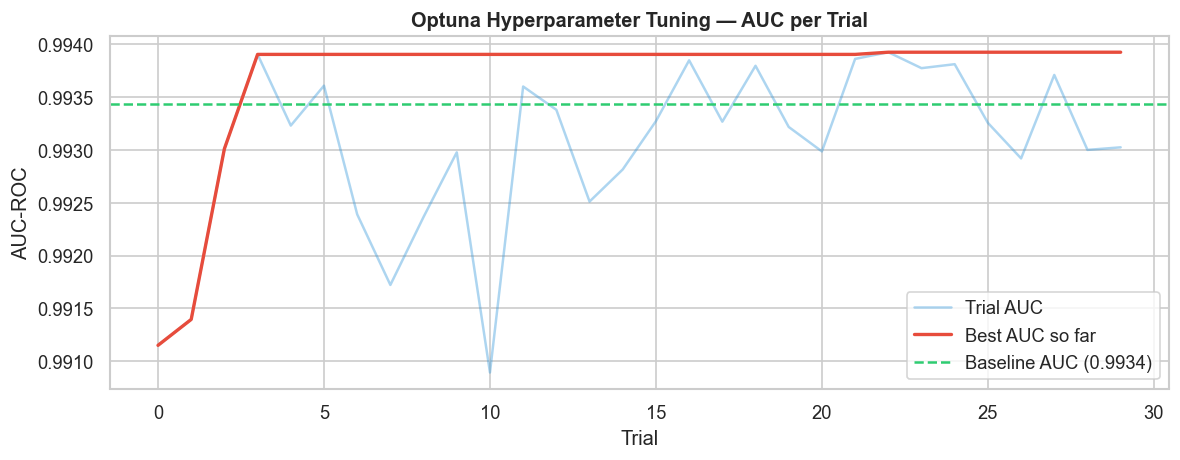

In [5]:
# ── Optuna trial history plot ──────────────────────────────────────────
trial_values = [t.value for t in study.trials]
best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trial_values, alpha=0.4, color='#3498DB', label='Trial AUC')
ax.plot(best_so_far, color='#E74C3C', linewidth=2, label='Best AUC so far')
ax.axhline(baseline_auc, color='#2ECC71', linestyle='--', linewidth=1.5, label=f'Baseline AUC ({baseline_auc:.4f})')
ax.set_title('Optuna Hyperparameter Tuning — AUC per Trial', fontweight='bold', fontsize=12)
ax.set_xlabel('Trial')
ax.set_ylabel('AUC-ROC')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/optuna_trials.png', bbox_inches='tight')
plt.show()

---
## 5. Train Final Model on Best Params

In [6]:
# Train final model with best hyperparameters from Optuna
best_params = study.best_params
best_params.update({
    'scale_pos_weight':  scale_pos_weight,
    'use_label_encoder': False,
    'eval_metric':       'auc',
    'random_state':      42,
    'n_jobs':            -1
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_pred_proba_final)

print(f'Final Model AUC-ROC: {final_auc:.4f}')
print(f'Baseline AUC-ROC:    {baseline_auc:.4f}')
print(f'Improvement:         +{final_auc - baseline_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, final_model.predict(X_test)))

Final Model AUC-ROC: 0.9939
Baseline AUC-ROC:    0.9934
Improvement:         +0.0005

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    192181
           1       0.92      1.00      0.96     38422

    accuracy                           0.99    230603
   macro avg       0.96      0.99      0.98    230603
weighted avg       0.99      0.99      0.99    230603



---
## 6. Feature Importance

Two ways to look at feature importance:
1. **XGBoost built-in** — based on how often each feature is used in splits
2. **SHAP** — based on marginal contribution of each feature to each prediction (more accurate)

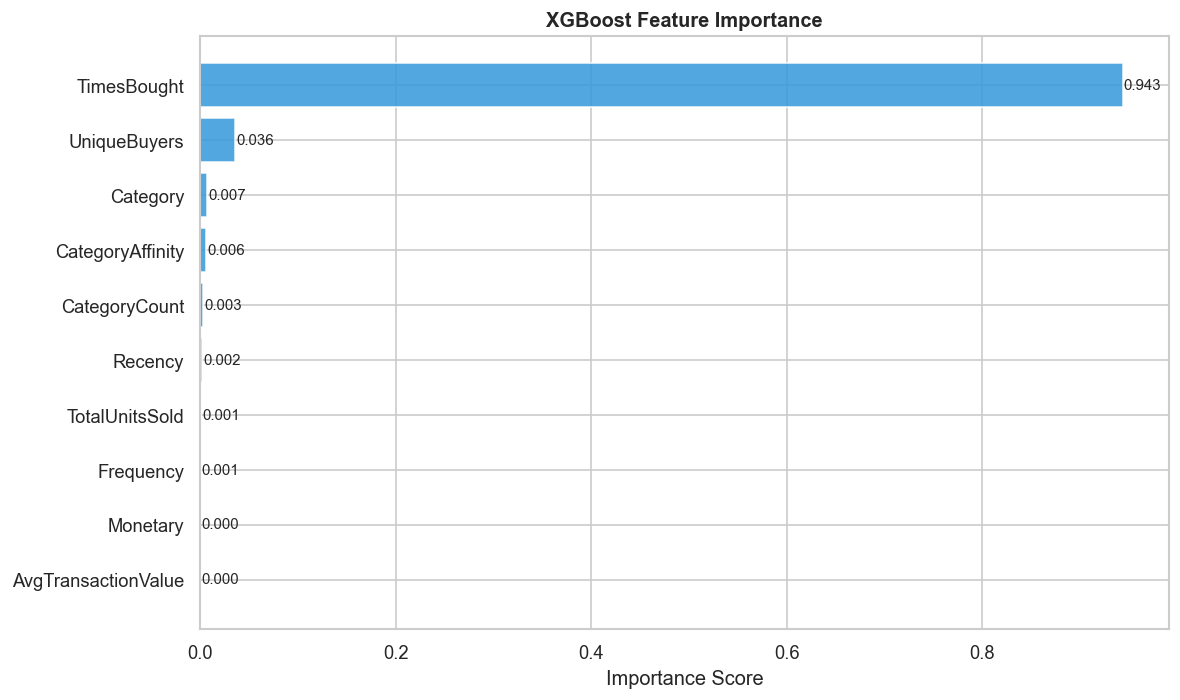

Top 5 most important features:
         Feature  Importance
   CategoryCount    0.003410
CategoryAffinity    0.006019
        Category    0.007063
    UniqueBuyers    0.036089
     TimesBought    0.943347


In [7]:
# ── XGBoost built-in feature importance ───────────────────────────────
importance_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#3498DB', edgecolor='white', alpha=0.85)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('XGBoost Feature Importance', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(importance_df.tail(5)[['Feature','Importance']].to_string(index=False))

---
## 7. SHAP Explainability

**Why SHAP over built-in feature importance?**  
Built-in importance tells you which features are used most — but not HOW they affect predictions.  
SHAP tells you: for each prediction, how much did each feature push the score up or down?

**Analogy:** Built-in importance = which players touched the ball most.  
SHAP = which players actually contributed to scoring goals.

**Two SHAP plots:**
1. **Summary plot** — global view: which features matter most and in which direction
2. **Waterfall plot** — local view: why did the model make THIS specific prediction

Computing SHAP values (this may take 1-2 minutes)...


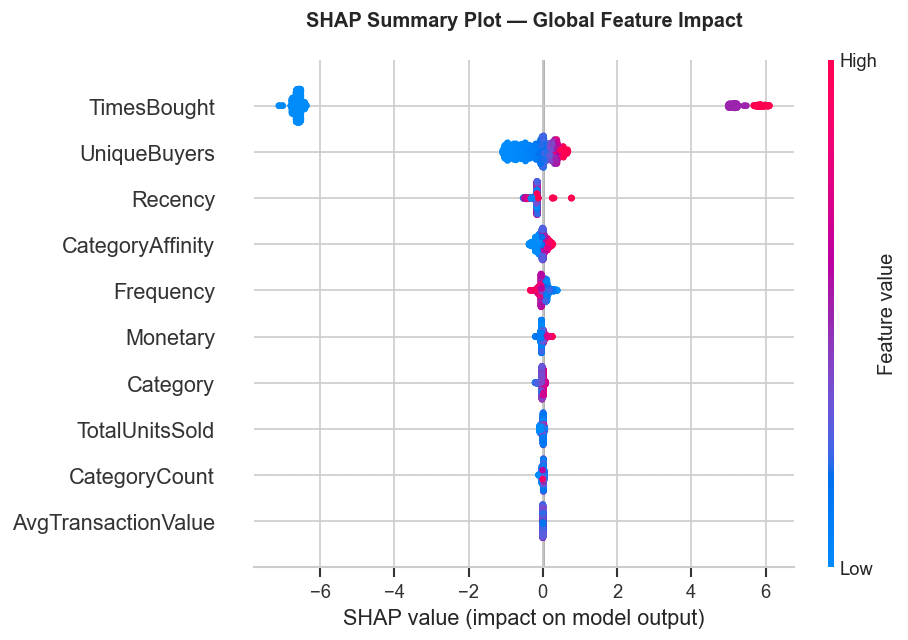


How to read this plot:
  - Each dot = one prediction
  - Red dot = high feature value | Blue dot = low feature value
  - Right of centre = pushes model to predict purchase (label=1)
  - Left of centre  = pushes model away from purchase (label=0)


In [8]:
# ── SHAP Global Summary ────────────────────────────────────────────────
# Use a sample for speed — SHAP is O(n) but large datasets take time
print('Computing SHAP values (this may take 1-2 minutes)...')

sample_idx  = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — shows direction and magnitude of each feature
# Red = high feature value, Blue = low feature value
# Right = pushes prediction higher (more likely to buy)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, plot_type='dot', show=False)
plt.title('SHAP Summary Plot — Global Feature Impact', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', bbox_inches='tight')
plt.show()

print('\nHow to read this plot:')
print('  - Each dot = one prediction')
print('  - Red dot = high feature value | Blue dot = low feature value')
print('  - Right of centre = pushes model to predict purchase (label=1)')
print('  - Left of centre  = pushes model away from purchase (label=0)')

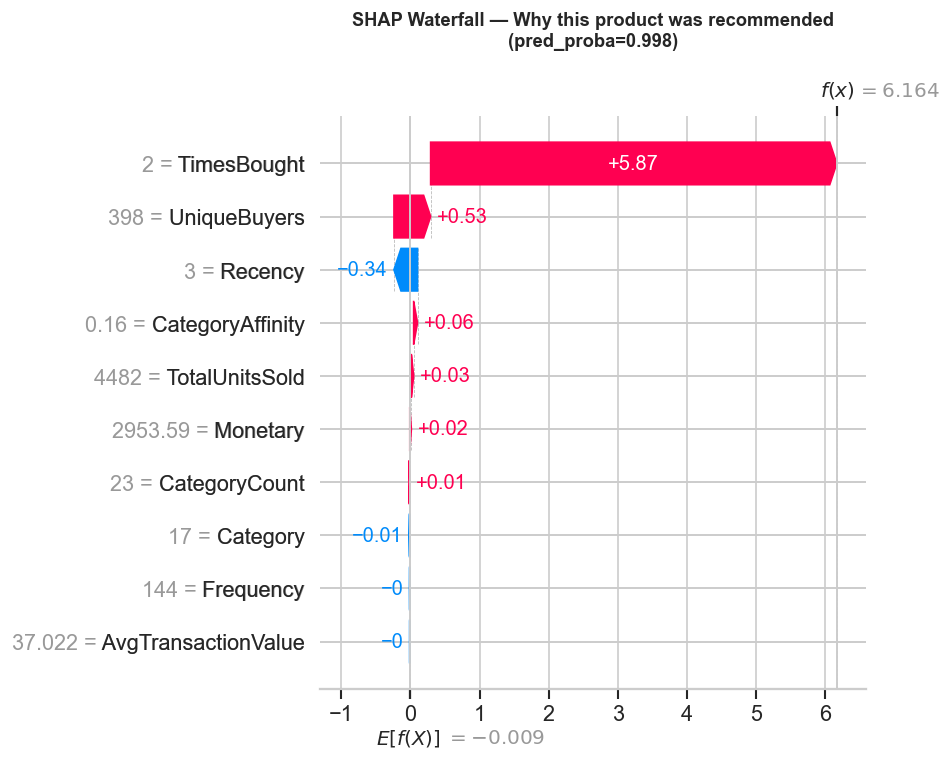

In [11]:
# ── SHAP Waterfall — Single Prediction Explanation ─────────────────────
# X_test_sample and shap_values both have 2000 rows (positional index 0-1999)
# We work purely in positional indices — no original DataFrame indices
preds_sample  = final_model.predict_proba(X_test_sample)[:, 1]
labels_sample = y_test.iloc[sample_idx].values

# Find a true positive with high confidence using positional index
high_conf_mask      = (labels_sample == 1) & (preds_sample > 0.7)
high_conf_positions = np.where(high_conf_mask)[0]

if len(high_conf_positions) > 0:
    pos = high_conf_positions[0]  # positional index into shap_values (0-1999)
    
    shap_exp = shap.Explanation(
        values        = shap_values[pos],
        base_values   = explainer.expected_value,
        data          = X_test_sample.iloc[pos].values,
        feature_names = FEATURE_COLS
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_exp, show=False)
    plt.title(f'SHAP Waterfall — Why this product was recommended\n(pred_proba={preds_sample[pos]:.3f})',
              fontweight='bold', fontsize=11, pad=20)
    plt.tight_layout()
    plt.savefig('../outputs/shap_waterfall.png', bbox_inches='tight')
    plt.show()
else:
    print('No high-confidence positives found — lowering threshold to 0.5')
    pos = np.where(labels_sample == 1)[0][0]
    shap_exp = shap.Explanation(
        values        = shap_values[pos],
        base_values   = explainer.expected_value,
        data          = X_test_sample.iloc[pos].values,
        feature_names = FEATURE_COLS
    )
    shap.plots.waterfall(shap_exp)

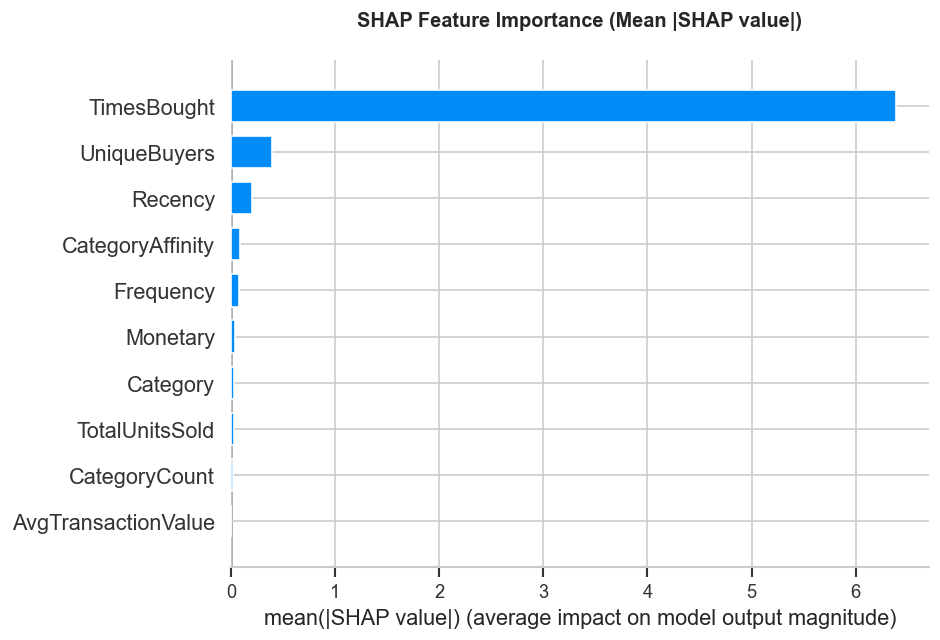

Top 5 features by mean SHAP impact:
         Feature  Mean_SHAP
     TimesBought   6.383224
    UniqueBuyers   0.395014
         Recency   0.206485
CategoryAffinity   0.091056
       Frequency   0.076335


In [12]:
# ── SHAP Bar Plot — Mean Absolute Impact ──────────────────────────────
# Shows average magnitude of each feature's impact across all predictions
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', bbox_inches='tight')
plt.show()

# Mean absolute SHAP values per feature
mean_shap = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print('Top 5 features by mean SHAP impact:')
print(mean_shap.head(5).to_string(index=False))

---
## 8. Save Model + Predictions

In [13]:
# Save model
joblib.dump(final_model, '../models/xgboost_recommender.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

# Save test predictions for Notebook 05 evaluation
test_data['pred_proba'] = final_model.predict_proba(X_test)[:, 1]
test_data.to_csv('../data/test_predictions.csv', index=False)

print('=' * 50)
print('        MODEL TRAINING SUMMARY')
print('=' * 50)
print(f'Baseline AUC-ROC:    {baseline_auc:.4f}')
print(f'Final AUC-ROC:       {final_auc:.4f}')
print(f'Improvement:         +{final_auc - baseline_auc:.4f}')
print('-' * 50)
print(f'Features used:       {len(FEATURE_COLS)}')
print(f'Training samples:    {len(X_train):,}')
print(f'Test samples:        {len(X_test):,}')
print(f'scale_pos_weight:    {scale_pos_weight:.2f}')
print('-' * 50)
print('Saved:')
print('  models/xgboost_recommender.pkl')
print('  models/label_encoder.pkl')
print('  data/test_predictions.csv')
print('=' * 50)
print('Next → Notebook 05: Precision@K, Recall@K, NDCG@K')

        MODEL TRAINING SUMMARY
Baseline AUC-ROC:    0.9934
Final AUC-ROC:       0.9939
Improvement:         +0.0005
--------------------------------------------------
Features used:       10
Training samples:    1,025,731
Test samples:        230,603
scale_pos_weight:    5.00
--------------------------------------------------
Saved:
  models/xgboost_recommender.pkl
  models/label_encoder.pkl
  data/test_predictions.csv
Next → Notebook 05: Precision@K, Recall@K, NDCG@K
